# Task 1: Data Cleaning and Visualization

## Project: E-Commerce Customer Analytics

### Objective
To clean the raw e-commerce dataset, handle missing values and duplicates, perform exploratory data analysis, and generate visualizations to uncover customer purchasing patterns and business insights.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


pd.set_option('display.max_columns', None)

plt.rcParams['figure.figsize'] = (10,6)

In [6]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/vijayuv/onlineretail/OnlineRetail.csv


In [7]:
df = pd.read_csv(
    '/kaggle/input/datasets/vijayuv/onlineretail/OnlineRetail.csv',
    encoding='latin1'
)

In [8]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [9]:
df.shape

(541909, 8)

In [10]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [12]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [13]:
missing_percent = (df.isnull().sum()/len(df))*100
missing_percent.sort_values(ascending=False)

CustomerID     24.926694
Description     0.268311
StockCode       0.000000
InvoiceNo       0.000000
Quantity        0.000000
InvoiceDate     0.000000
UnitPrice       0.000000
Country         0.000000
dtype: float64

In [14]:
df = df.dropna()

In [15]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [16]:
df.duplicated().sum()

np.int64(5225)

In [17]:
df = df.drop_duplicates()

In [18]:
df.duplicated().sum()

np.int64(0)

In [19]:
df.shape

(401604, 8)

In [20]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,401604.000000,401604.000000,401604.000000
mean,12.183273,3.474064,15281.160818
std,250.283037,69.764035,1714.006089
min,-80995.000000,0.000000,12346.000000
25%,2.000000,1.250000,13939.000000
50%,5.000000,1.950000,15145.000000
75%,12.000000,3.750000,16784.000000
max,80995.000000,38970.000000,18287.000000


In [21]:
df['Revenue'] = df['Quantity'] * df['UnitPrice']

In [22]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34


In [23]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 401604 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    401604 non-null  object        
 1   StockCode    401604 non-null  object        
 2   Description  401604 non-null  object        
 3   Quantity     401604 non-null  int64         
 4   InvoiceDate  401604 non-null  datetime64[ns]
 5   UnitPrice    401604 non-null  float64       
 6   CustomerID   401604 non-null  float64       
 7   Country      401604 non-null  object        
 8   Revenue      401604 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 30.6+ MB


In [25]:
df['Month'] = df['InvoiceDate'].dt.month

In [26]:
df[['InvoiceDate','Month']].head()

,InvoiceDate,Month
0,2010-12-01 08:26:00,12
1,2010-12-01 08:26:00,12
2,2010-12-01 08:26:00,12
3,2010-12-01 08:26:00,12
4,2010-12-01 08:26:00,12


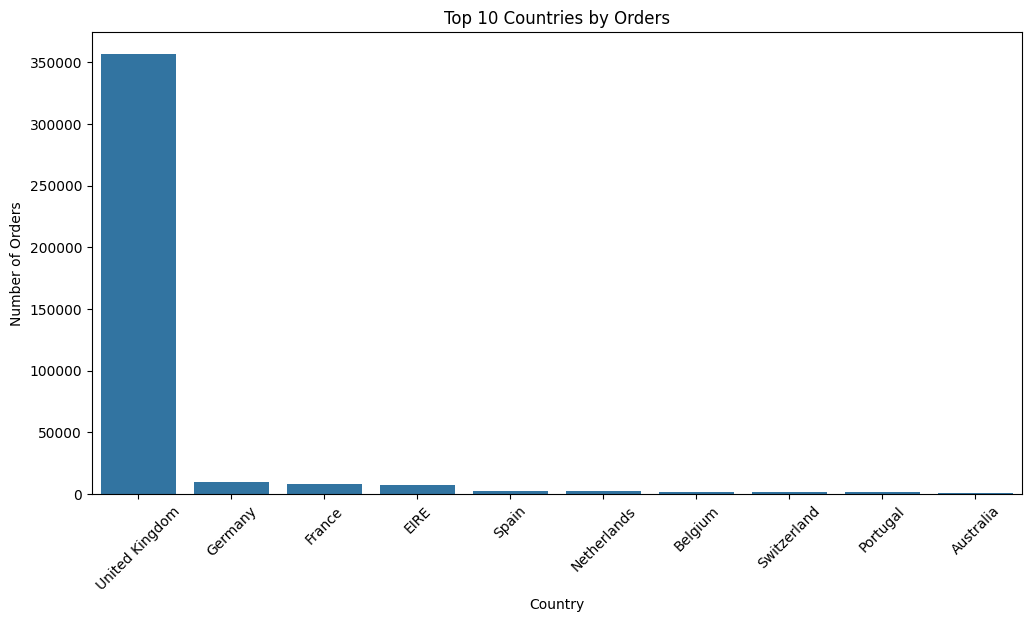

In [28]:
top_countries = df['Country'].value_counts().head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_countries.index,
    y=top_countries.values
)

plt.title('Top 10 Countries by Orders')
plt.xlabel('Country')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)

plt.show()

### Observation

The United Kingdom generated the highest number of orders, indicating that it is the primary market for the business.

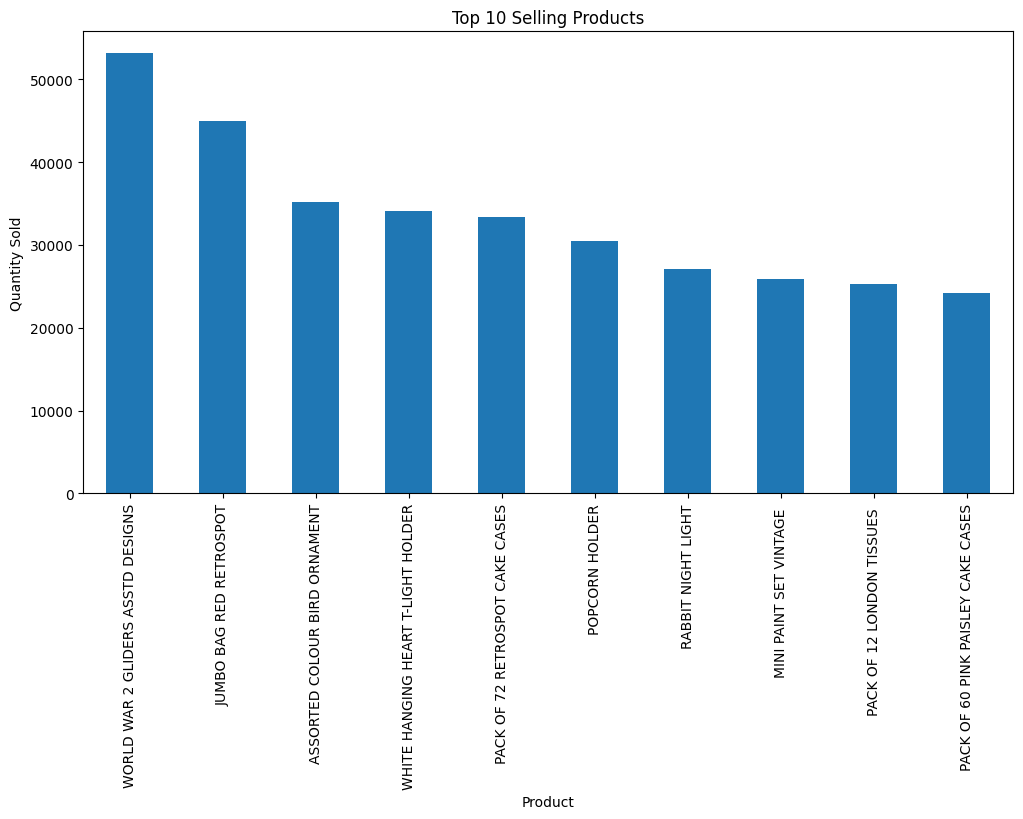

In [29]:
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))

top_products.plot(kind='bar')

plt.title('Top 10 Selling Products')
plt.xlabel('Product')
plt.ylabel('Quantity Sold')
plt.xticks(rotation=90)

plt.show()

### Observation

A small number of products contribute significantly to total sales volume, highlighting their importance in inventory planning.

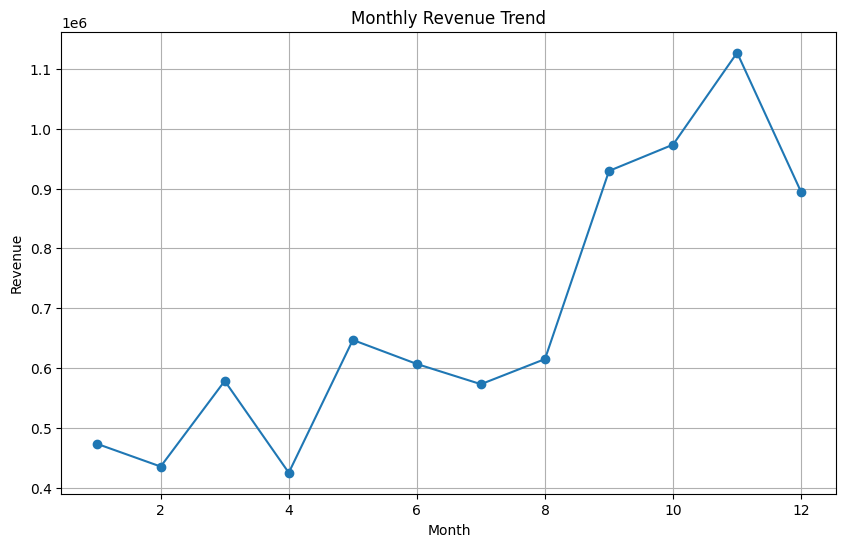

In [30]:
monthly_sales = df.groupby('Month')['Revenue'].sum()

plt.figure(figsize=(10,6))

monthly_sales.plot(marker='o')

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.grid(True)

plt.show()

### Observation

Monthly revenue shows an overall increasing trend throughout the year. Revenue peaks in November, indicating a strong seasonal effect, likely due to holiday and festive shopping. A slight decline is observed in December, but revenue remains significantly higher than the initial months.

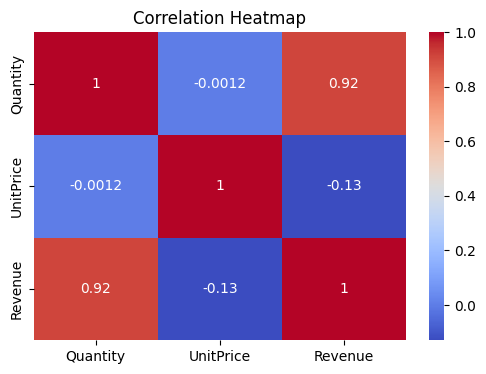

In [31]:
corr = df[['Quantity','UnitPrice','Revenue']].corr()

plt.figure(figsize=(6,4))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

### Observation

Revenue is positively correlated with Quantity, indicating that larger purchases contribute directly to higher revenue generation.

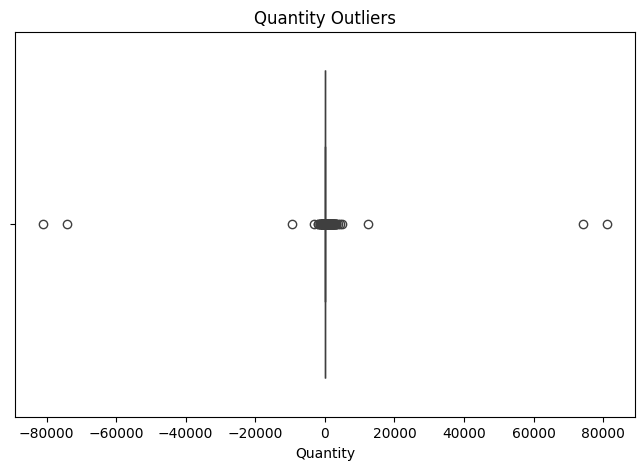

In [32]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df['Quantity'])

plt.title('Quantity Outliers')

plt.show()

### Observation

The boxplot reveals the presence of extreme outliers in the Quantity column. These outliers likely represent bulk purchases or large business orders and can significantly influence statistical measures such as the mean.

# Key Insights

1. The United Kingdom generated the highest number of orders and dominates the customer base.

2. A small set of products contributes significantly to total sales volume.

3. Revenue shows a strong increase during the last quarter of the year.

4. November recorded the highest revenue, indicating seasonal shopping trends.

5. Most transactions generate low revenue, while a few transactions contribute exceptionally high revenue.

6. Significant outliers exist in purchase quantity, suggesting bulk buying behavior.

7. Quantity and Revenue exhibit a positive relationship.

8. The cleaned dataset provides valuable business insights for future predictive modeling and recommendation systems.

# Conclusion

The Online Retail dataset was successfully cleaned and analyzed using Python, Pandas, Matplotlib, and Seaborn.

Missing values and duplicate records were identified and removed to improve data quality. Several visualizations were created to analyze customer purchasing behavior, product demand, country-wise order distribution, and revenue trends.

The analysis revealed that the United Kingdom is the primary market, a few products drive a large portion of sales, and revenue increases significantly during the holiday season.

The cleaned dataset and extracted insights can serve as a foundation for future machine learning applications such as customer segmentation, sales forecasting, recommendation systems, and customer behavior prediction.